In [47]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
p = Path("/home/finn/workspace/creatures/logs/simulation_1782655070.log")
assert p.exists()

In [64]:
with open(p, "r") as f:
    lines = f.readlines()

print(len(lines))

19937


In [65]:
def extract_animal_data(line):
    # Match new log format: [unix_ts=...] [frame=...] animal_despawn reason=... lifetime_frames=... animal=Animal { ... }
    pat = (
        r".*"
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_timestamp>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"animal_despawn "
        r"reason=(?P<reason>\w+) "
        r"lifetime_frames=(?P<lifetime>\d+) "
        r"animal=Animal\s*\{ "
        r"id:\s*(?P<id>\d+),\s*"
        r"parent_id:\s*Some\((?P<parent_id>\d+|None)\),\s*"
        r"diet:\s*(?P<diet>\w+),\s*"
        r".*"
        r"family:\s*(?P<family>\d+)\s*\}"
        r".*"
    )

    m = re.match(
        pat,
        line,
    )

    if m is not None:
        d = {}
        d["simulation_start_ts"] = m.group("simulation_start_ts")
        d["unix_timestamp"] = float(m.group("unix_timestamp"))
        d["lifetime"] = float(m.group("lifetime"))
        d["diet"] = m.group("diet")
        d["family"] = int(m.group("family"))
        d["id"] = int(m.group("id"))
        d["parent_id"] = m.group("parent_id")
        return d
    return None


In [66]:
df = pd.DataFrame(list(filter(None, map(extract_animal_data, lines))))


In [67]:
df

,simulation_start_ts,unix_timestamp,lifetime,diet,family,id,parent_id
0,1782655070,1.782655e+09,647.0,Herbivore,3733104254,13295893300891834177,13043947048385484522
1,1782655070,1.782655e+09,657.0,Herbivore,3733104254,408737140360189020,5345012208910177129
2,1782655070,1.782655e+09,656.0,Herbivore,3733104254,8955098678174487324,5049851694432970009
3,1782655070,1.782655e+09,672.0,Herbivore,3733104254,3218557381868880035,5345012208910177129
4,1782655070,1.782655e+09,668.0,Herbivore,3733104254,6836033605830041453,4068978664730334588
...,...,...,...,...,...,...,...
4112,1782655070,1.782656e+09,2723.0,Omnivore,2690928774,4709744761389587530,7476698237015507857
4113,1782655070,1.782656e+09,1319.0,Omnivore,2690928774,496375552632369986,14069824117433908786
4114,1782655070,1.782656e+09,1139.0,Herbivore,4002624433,5953499668570534971,9742331029610880126
4115,1782655070,1.782656e+09,291.0,Herbivore,4002624433,9689442443295519291,2770272401679516630


<Axes: xlabel='diet', ylabel='lifetime'>

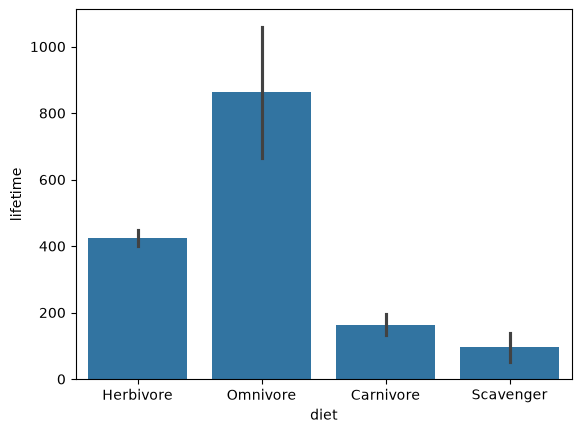

In [68]:
sns.barplot(data=df, x="diet", y="lifetime")

<Axes: xlabel='family', ylabel='lifetime'>

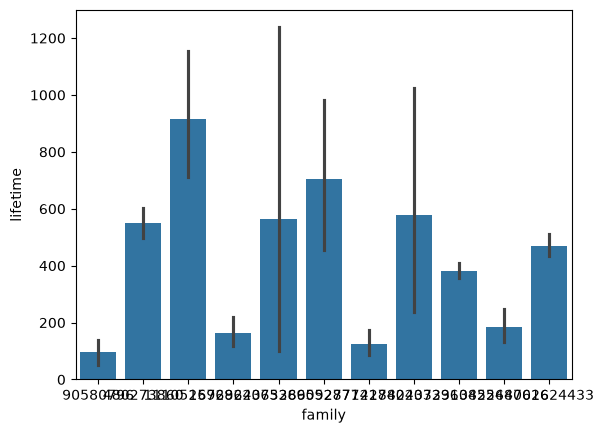

In [69]:
sns.barplot(data=df, x="family", y="lifetime")

# Population

In [70]:
def extract_population_data(line):
    m = re.match(
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_ts>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"population_size "
        r"plants=(?P<plants>\d+) "
        r"animals=\{(?P<animals>[^}]+)\} "
        r"families=(?P<families>\d+:\d+(?:\|\d+:\d+)*)",
        line,
    )
    if m is None:
        return None

    animals = {k: int(v) for k, v in (pair.split(":") for pair in m.group("animals").split())}
    families = [tuple(map(int, f.split(":"))) for f in m.group("families").split("|")]

    return {
        "simulation_start_ts": int(m.group("simulation_start_ts")),
        "unix_ts": int(m.group("unix_ts")),
        "frame": int(m.group("frame")),
        "n_plants": int(m.group("plants")),
        "carnivores": animals.get("carnivores", 0),
        "herbivores": animals.get("herbivores", 0),
        "omnivores": animals.get("omnivores", 0),
        "scavengers": animals.get("scavengers", 0),
        "families": families,
    }


In [71]:
df = pd.DataFrame(list(filter(None, map(extract_population_data, lines)))).set_index("frame")
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
12,1782655070,1782655070,11,1,0,0,0,"[(0, 1)]"
45,1782655070,1782655070,12,1,0,0,0,"[(0, 1)]"
73,1782655070,1782655071,13,1,0,0,0,"[(0, 1)]"
164,1782655070,1782655072,14,1,0,0,0,"[(0, 1)]"
228,1782655070,1782655074,15,1,0,0,0,"[(0, 1)]"
...,...,...,...,...,...,...,...,...
28662,1782655070,1782656089,18,0,18,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."
28663,1782655070,1782656089,18,0,17,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."
28675,1782655070,1782656089,18,0,16,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."


### Genetic DIversity

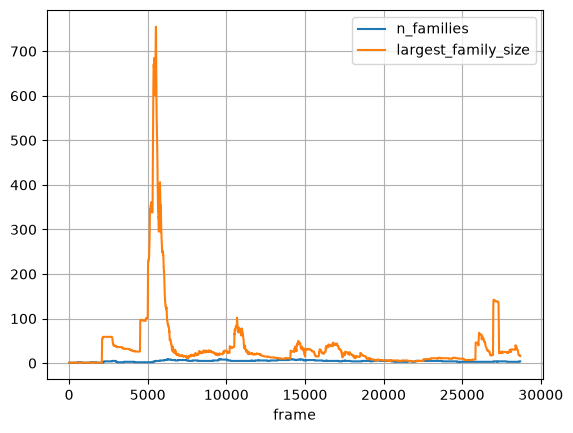

In [72]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

plt.grid(True)

### Population

In [73]:
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
12,1782655070,1782655070,11,1,0,0,0,"[(0, 1)]"
45,1782655070,1782655070,12,1,0,0,0,"[(0, 1)]"
73,1782655070,1782655071,13,1,0,0,0,"[(0, 1)]"
164,1782655070,1782655072,14,1,0,0,0,"[(0, 1)]"
228,1782655070,1782655074,15,1,0,0,0,"[(0, 1)]"
...,...,...,...,...,...,...,...,...
28662,1782655070,1782656089,18,0,18,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."
28663,1782655070,1782656089,18,0,17,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."
28675,1782655070,1782656089,18,0,16,24,1,"[(1110525968, 8), (1220437956, 1), (2690928774..."


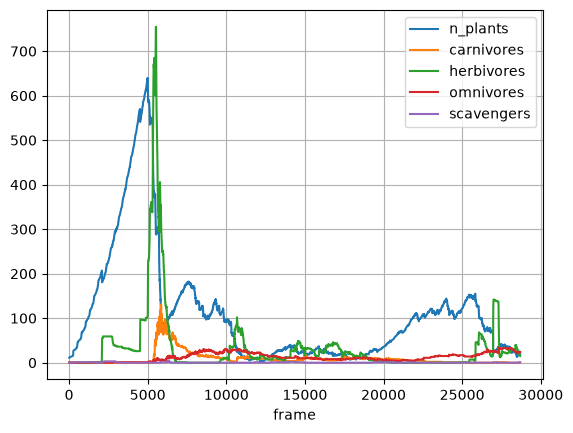

In [74]:
#df["n_plants"].plot()
df[["n_plants","carnivores", "herbivores", "omnivores", "scavengers"]].plot()
plt.grid()
plt.legend()